In [ ]:
import marimo as mo  # comment the import if not using marimo notebook editor
import cv2 as cv
import dlib
import numpy as np
import matplotlib.pyplot as plt
import random
from time import perf_counter
from typing import NamedTuple

# Some useful types
Color = tuple[int, int, int]
RgbImage = np.ndarray[tuple[int, int, int], np.dtype[np.uint8]]
GrayImage = np.ndarray[tuple[int, int], np.dtype[np.uint8]]

class Image(NamedTuple):
    name: str
    rgb: RgbImage
    gray: GrayImage

# CV Lab 9 — Face Detection Demo

Select an image, toggle grayscale, and adjust the scale to compare dlib and Viola-Jones side by side.

In [ ]:
# Define some utility functions

def load_image(name: str) -> Image:
    bgr = cv.imread(f'data/{name}.jpg')
    rgb: RgbImage = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    gray: GrayImage = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    return Image(name, rgb, gray)

def random_color() -> Color:
    return (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

In [ ]:
# Load the images for demo
images: dict[str, Image] = {
    name: load_image(name) for name in [
        "in-glasses", "paint", "bike", "cave",
        "group", "masks", "run", "beatles", "drawing",
    ]
}

In [ ]:
detector = dlib.get_frontal_face_detector()
cascade = cv.CascadeClassifier('data/haarcascade_frontalface_default.xml')
predictor = dlib.shape_predictor('data/shape_predictor_68_face_landmarks.dat')

In [ ]:
# Utility for detecting faces using dblib
def detect_dlib(img: Image, *, gray: bool = False, scale: float = 1.0, thickness: int = 3) -> tuple[np.ndarray, dict]:
    source = np.copy(img.gray if gray else img.rgb)

    if scale != 1.0:
        source = cv.resize(source, (0, 0), fx=scale, fy=scale)

    # Detect faces rectangles with measuring the elapsed time
    start = perf_counter()
    rects = detector(source, 1)
    elapsed = perf_counter() - start

    # Draw rectangles on the source
    for rect in rects:
        cv.rectangle(source, (rect.left(), rect.top()), (rect.right(), rect.bottom()), random_color(), thickness)

    return source, {'rects': [(r.left(), r.top(), r.right(), r.bottom()) for r in rects], 'time': elapsed}

In [ ]:
# Utility for detecting faces using Voila-Jones
def detect_vj(img: Image, *, gray: bool = False, scale: float = 1.0, thickness: int = 3) -> tuple[np.ndarray, dict]:
    source = np.copy(img.gray if gray else img.rgb)

    if scale != 1.0:
        source = cv.resize(source, (0, 0), fx=scale, fy=scale)

    # Detect faces with measuring the elapsed time
    start = perf_counter()
    faces = cascade.detectMultiScale(source, scaleFactor=1.1, minNeighbors=10, flags=cv.CASCADE_SCALE_IMAGE)
    elapsed = perf_counter() - start

    # Draw rectangles on the source
    for (x, y, w, h) in faces:
        cv.rectangle(source, (x, y), (x + w, y + h), random_color(), thickness)

    return source, {'rects': [(x, y, x + w, y + h) for (x, y, w, h) in faces], 'time': elapsed}

In [ ]:
# Landmark utils go here

def plot_landmarks(vec):
    plt.plot(vec[0:17,0], vec[0:17,1], 'g.-')       # Contour
    plt.plot(vec[48:68,0], vec[48:68,1], 'g.-')     # Mouth
    plt.plot(vec[17:22,0], vec[17:22,1], 'g.-')     # Right eyebrow
    plt.plot(vec[22:27,0], vec[22:27,1], 'g.-')     # Left eyebrow
    plt.plot(np.concatenate((vec[36:42,0], vec[36:37,0])), np.concatenate((vec[36:42,1], vec[36:37,1])), 'g.-')     # Left eye
    plt.plot(np.concatenate((vec[42:48,0], vec[42:43,0])), np.concatenate((vec[42:48,1], vec[42:43,1])), 'g.-')     # Right eye
    plt.plot(vec[27:36,0], vec[27:36,1], 'g.-')

In [ ]:
image_select = mo.ui.dropdown(list(images.keys()), value="in-glasses", label="Image")
gray_toggle = mo.ui.switch(label="Grayscale")
scale_slider = mo.ui.slider(0.1, 100.0, step=0.1, value=100.0, label="Scale (%)")
thickness_input = mo.ui.number(1, 30, step=1, value=3, label="Thickness")

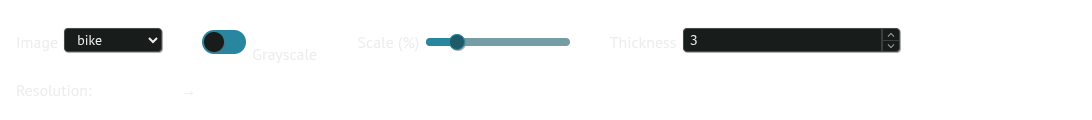

In [ ]:
_controls = mo.hstack([image_select, gray_toggle, scale_slider, thickness_input], justify="start", gap=2)

# Show image resolution change if downscale was applied
if scale_slider.value < 100.0:
    _scale = scale_slider.value / 100.0
    _h, _w = images[image_select.value].rgb.shape[:2]
    _info = mo.md(f"Resolution: **{_w}×{_h}** → **{int(_w * _scale)}×{int(_h * _scale)}**")
    _output = mo.vstack([_controls, _info])
else:
    _output = _controls

_output

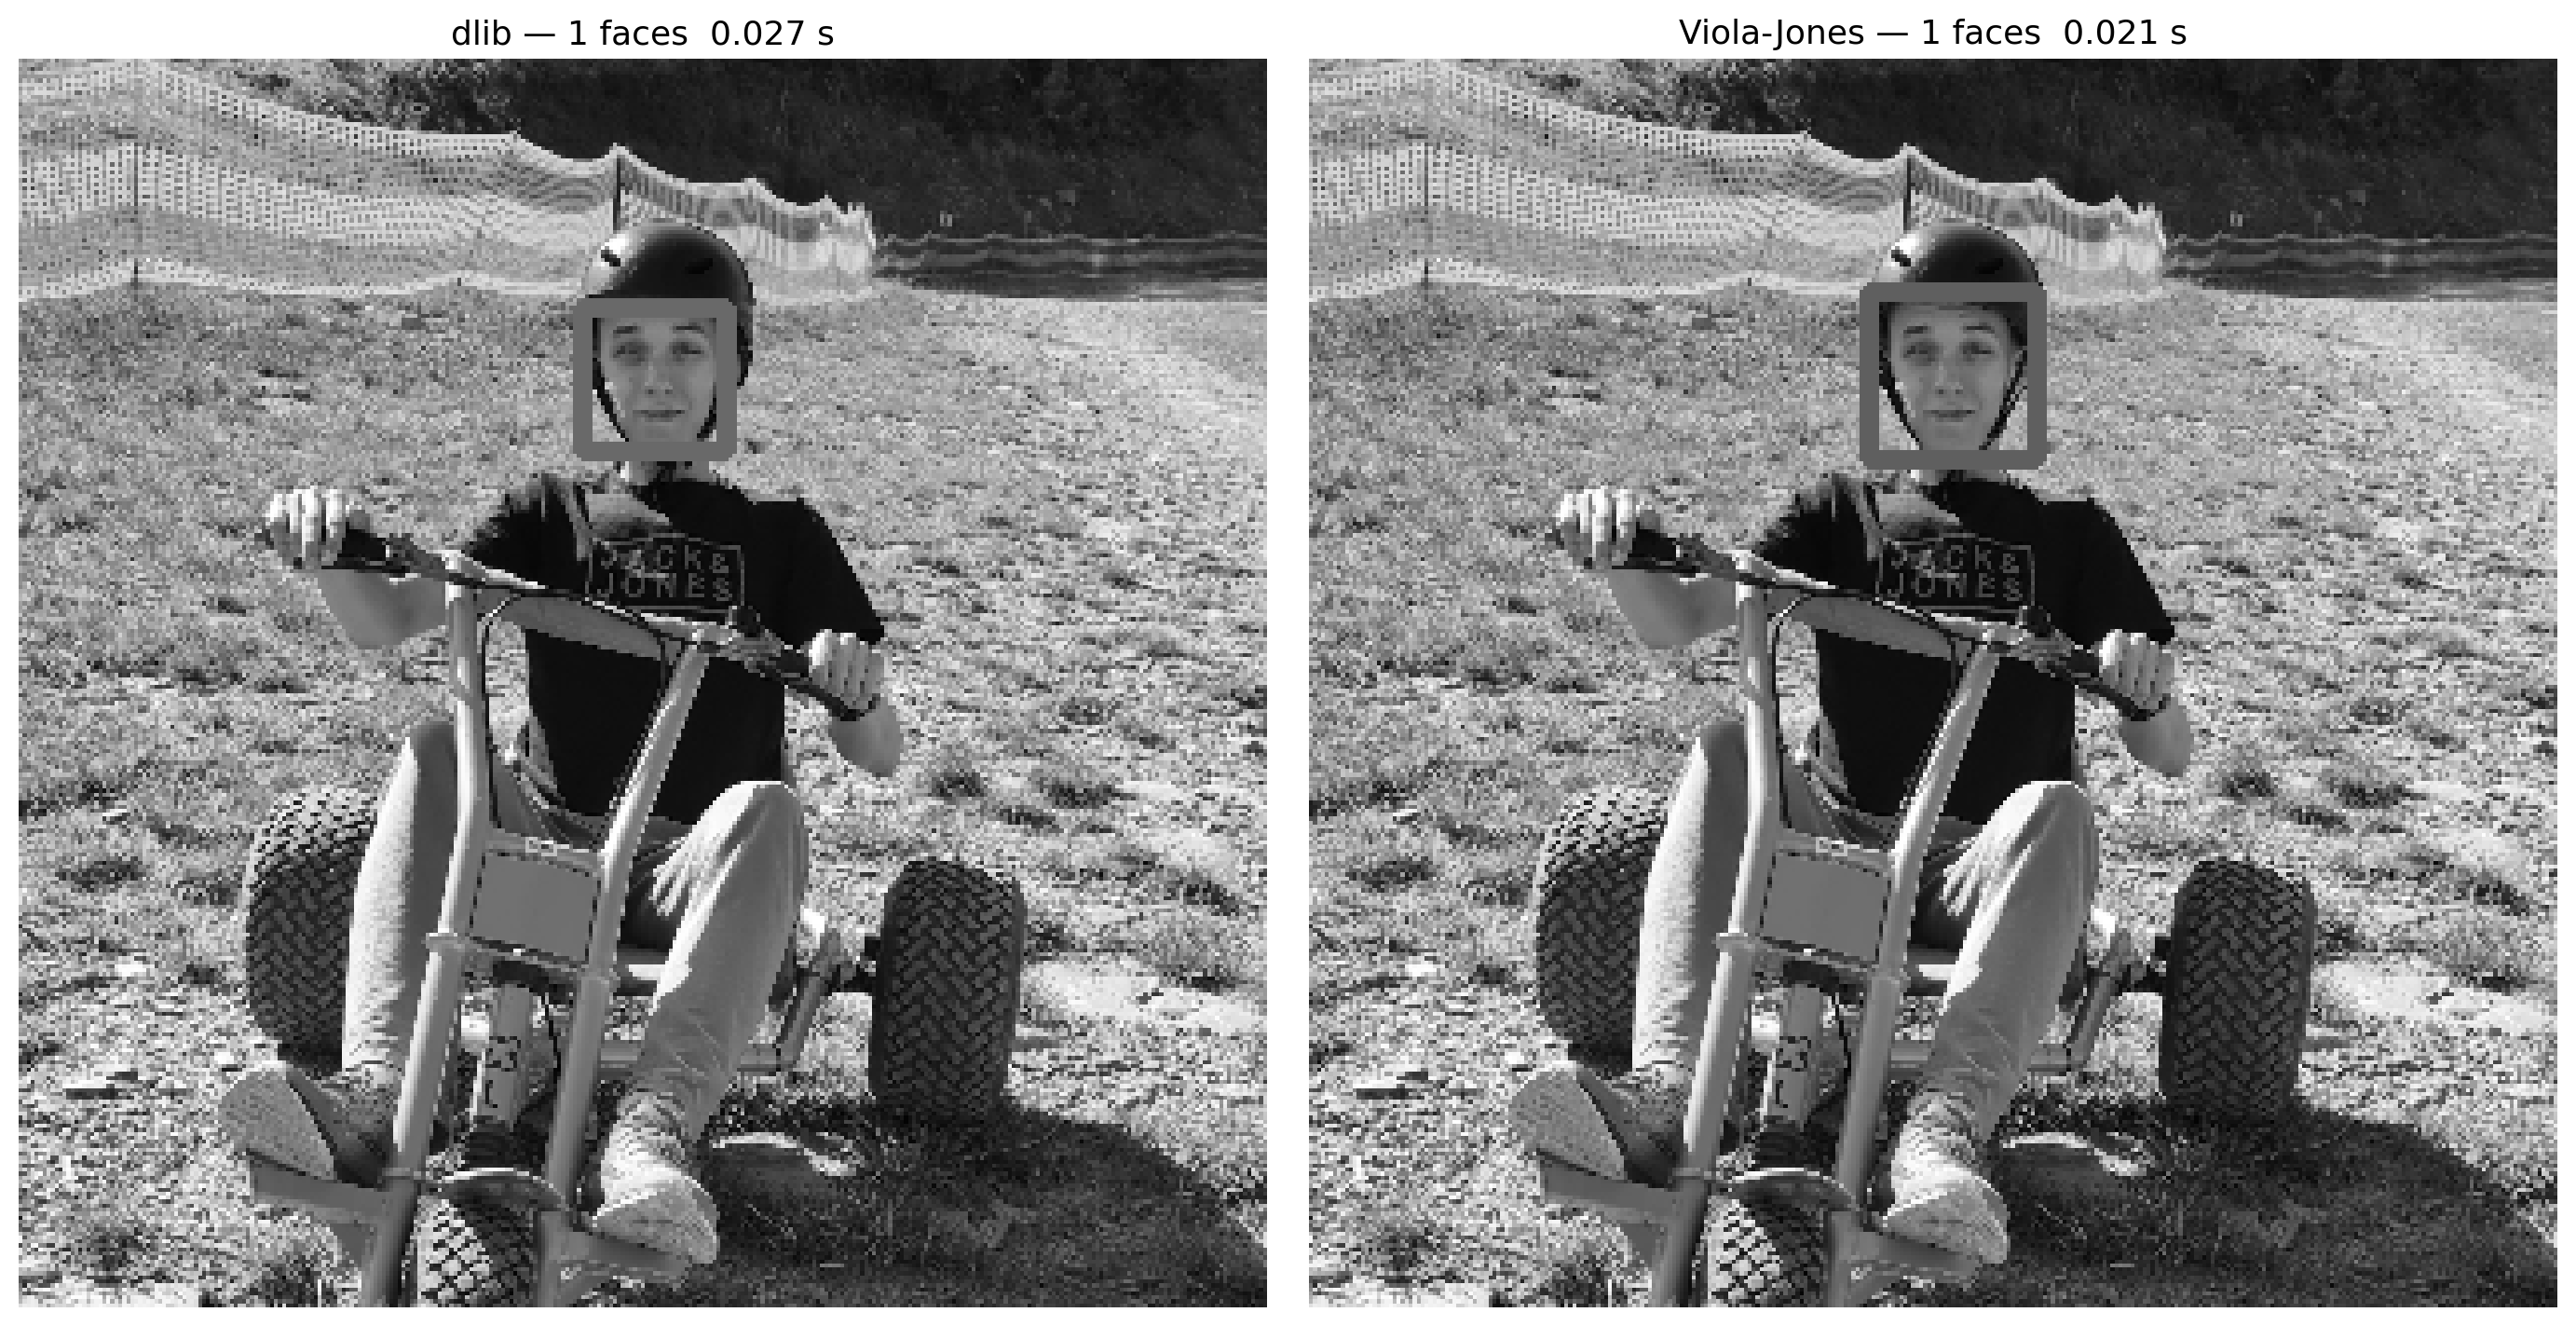

In [ ]:
# Gather values from UI elements
_img = images[image_select.value]
_gray = gray_toggle.value
_scale = scale_slider.value / 100.0
_thickness = int(thickness_input.value)

# Run the dectection using both methods
_dlib_img, _dlib_m = detect_dlib(_img, gray=_gray, scale=_scale, thickness=_thickness)
_vj_img, _vj_m = detect_vj(_img, gray=_gray, scale=_scale, thickness=_thickness)

# Combine, deduplicate, and sort left-to-right by top-left corner
detected_rects = sorted(dict.fromkeys(_dlib_m['rects'] + _vj_m['rects']), key=lambda r: (r[0], r[1]))

_cmap = "gray" if _gray else None
_fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Plot dlib result
_ax1.imshow(_dlib_img, cmap=_cmap)
_ax1.set_title(f"dlib — {len(_dlib_m['rects'])} faces  {_dlib_m['time']:.3f} s", fontsize=13)
_ax1.axis('off')

# Plot VJ result
_ax2.imshow(_vj_img, cmap=_cmap)
_ax2.set_title(f"Viola-Jones — {len(_vj_m['rects'])} faces  {_vj_m['time']:.3f} s", fontsize=13)
_ax2.axis('off')

plt.tight_layout()
plt.show()

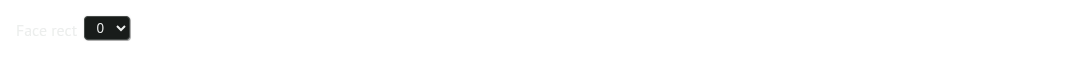

In [ ]:
_options = {str(i): rect for i, rect in enumerate(detected_rects)}
rect_select = mo.ui.dropdown(
    _options,
    value="0" if _options else None,
    label="Face rect",
)
rect_select

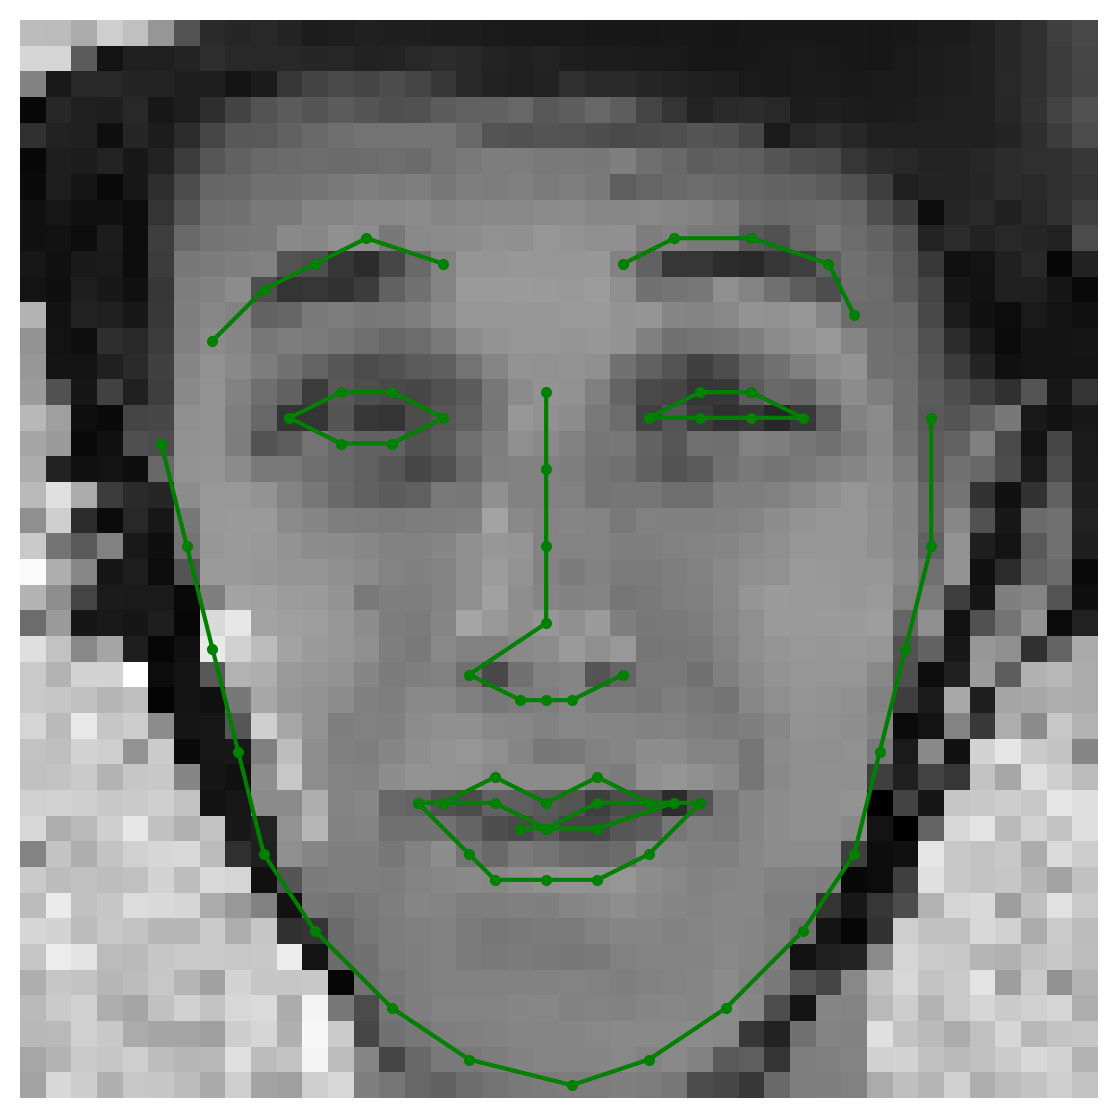

In [ ]:
# Prepare the (possibly scaled) source in the selected color mode
_scale = scale_slider.value / 100.0
_gray = gray_toggle.value
_img = images[image_select.value]

_source = _img.gray if _gray else _img.rgb
if _scale != 1.0:
    _source = cv.resize(_source, (0, 0), fx=_scale, fy=_scale)

# Crop to the selected rect, clamping coords to image bounds
_h, _w = _source.shape[:2]
_x1, _y1, _x2, _y2 = rect_select.value if rect_select.value else (0, 0, 0, 0)
_x1, _y1 = max(0, _x1), max(0, _y1)
_x2, _y2 = min(_w, _x2), min(_h, _y2)
_face = _source[_y1:_y2, _x1:_x2]

if _face.size == 0:
    mo.md("No faces detected — nothing to show.")
else:
    _shape = predictor(_face, dlib.rectangle(0, 0, _x2 - _x1, _y2 - _y1))
    _landmarks = np.array([(p.x, p.y) for p in _shape.parts()])

    plt.figure(figsize=(7, 7))
    plt.imshow(_face, cmap="gray" if _gray else None)
    plot_landmarks(_landmarks)
    plt.axis('off')
    plt.show()